# 可视化训练日志-训练过程总体评估指标

训练模型时在`work_dirs`目录生成记录训练日志，解析其中损失函数、评估指标等信息，并可视化。

同济子豪兄：https://space.bilibili.com/1900783

## 设置Matplotlib中文字体

In [1]:
# # windows操作系统
# plt.rcParams['font.sans-serif']=['SimHei']  # 用来正常显示中文标签 
# plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号

In [2]:
# Mac操作系统，参考 https://www.ngui.cc/51cto/show-727683.html
# 下载 simhei.ttf 字体文件
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf

In [1]:
# Linux操作系统，例如 云GPU平台：https://featurize.cn/?s=d7ce99f842414bfcaea5662a97581bd1
# 如果遇到 SSL 相关报错，重新运行本代码块即可
# !wget https://zihao-openmmlab.obs.cn-east-3.myhuaweicloud.com/20220716-mmclassification/dataset/SimHei.ttf -O /environment/miniconda3/lib/python3.7/site-packages/matplotlib/mpl-data/fonts/ttf/SimHei.ttf
# !rm -rf /home/featurize/.cache/matplotlib

import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc("font",family='SimHei') # 中文字体


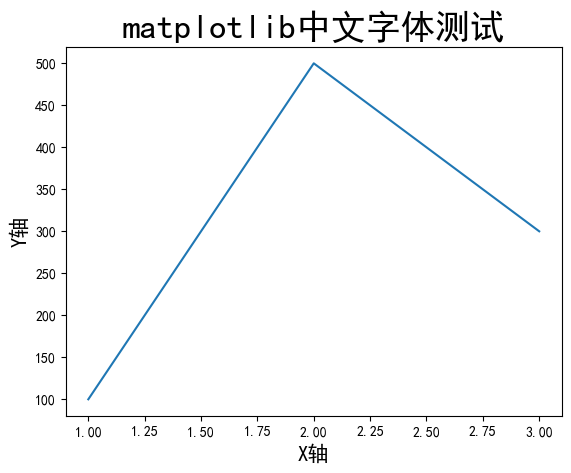

In [2]:
plt.plot([1,2,3], [100,500,300])
plt.title('matplotlib中文字体测试', fontsize=25)
plt.xlabel('X轴', fontsize=15)
plt.ylabel('Y轴', fontsize=15)
plt.show()

## 进入MMSegmentation主目录

In [3]:
# import os
# os.chdir('mmsegmentation')

import os
# 假设 mmsegmentation 的绝对路径是 /project/mmsegmentation
mmsegmentation_path = "E:/bishe_custom_data/mmsegmentation-main"
# 切换到 mmsegmentation 文件夹
os.chdir(mmsegmentation_path)
# 验证当前工作目录
print("当前工作目录:", os.getcwd())  # 输出: /project/mmsegmentation

当前工作目录: E:\bishe_custom_data\mmsegmentation-main


In [4]:
os.getcwd()

'E:\\bishe_custom_data\\mmsegmentation-main'

## 导入工具包

In [4]:
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

## 载入训练日志

In [5]:
# 日志文件路径
log_path = './work_dirs/ZihaoDataset-DeepLabV3plus/20250317_111401/vis_data/scalars.json'

In [6]:
with open(log_path, "r") as f:
    json_list = f.readlines()

In [7]:
len(json_list)

550

In [8]:
eval(json_list[4])

{'lr': 0.009989084308262066,
 'data_time': 0.21954963207244874,
 'loss': 1.2709871649742126,
 'decode.loss_ce': 0.7539563655853272,
 'decode.acc_seg': 53.452205657958984,
 'aux.loss_ce': 0.5170307993888855,
 'aux.acc_seg': 57.047176361083984,
 'time': 0.955685043334961,
 'iter': 50,
 'memory': 5187,
 'step': 50}

In [9]:
import pandas as pd

# 初始化空的 DataFrame
df_train = pd.DataFrame()
df_test = pd.DataFrame()

# 遍历 json_list
for each in json_list[:-1]:
    # 将字符串转换为字典
    data = eval(each)
    
    # 根据条件将数据添加到 df_train 或 df_test
    if 'aAcc' in data:
        df_test = pd.concat([df_test, pd.DataFrame([data])], ignore_index=True)
    else:
        df_train = pd.concat([df_train, pd.DataFrame([data])], ignore_index=True)

In [10]:
df_train

,lr,data_time,loss,decode.loss_ce,decode.acc_seg,aux.loss_ce,aux.acc_seg,time,iter,memory,step
0,0.009998,0.004032,1.223868,0.668991,44.914532,0.554877,61.303043,1.978166,10,5978,10
1,0.009996,0.196579,1.250228,0.713587,28.139687,0.536640,45.673847,0.910448,20,5187,20
2,0.009994,0.218029,1.124732,0.637133,15.118217,0.487599,77.662086,0.936606,30,5187,30
3,0.009991,0.236551,1.213092,0.741637,16.055965,0.471455,63.235474,0.975628,40,5187,40
4,0.009989,0.219550,1.270987,0.753956,53.452206,0.517031,57.047176,0.955685,50,5187,50
...,...,...,...,...,...,...,...,...,...,...,...
495,0.008888,0.179939,0.351881,0.208184,88.297081,0.143698,80.909348,0.916444,4960,5187,4960
496,0.008886,0.171021,0.475393,0.298465,92.700104,0.176927,86.556244,0.898767,4970,5187,4970
497,0.008884,0.174553,0.384299,0.218460,92.224884,0.165839,90.926743,0.911004,4980,5187,4980
498,0.008881,0.182453,0.440082,0.275966,86.364273,0.164116,87.223816,0.915095,4990,5187,4990


In [11]:
df_test

,aAcc,mIoU,mAcc,mDice,mFscore,mPrecision,mRecall,data_time,time,step
0,23.24,10.65,39.61,18.69,18.69,29.29,39.61,0.183743,2.453326,100
1,69.12,22.02,31.66,30.43,38.03,40.89,31.66,0.002038,0.317907,200
2,77.91,22.06,34.71,29.26,29.26,53.96,34.71,0.003572,0.328899,300
3,71.20,26.41,47.68,36.37,36.37,64.51,47.68,0.003311,0.328161,400
4,78.53,31.99,43.84,44.44,44.44,56.08,43.84,0.002083,0.331908,500
5,84.80,49.48,62.90,63.71,63.71,67.18,62.90,0.003603,0.331231,600
6,81.35,35.36,62.27,47.42,47.42,55.72,62.27,0.003341,0.333686,700
7,81.23,43.42,59.62,57.17,57.17,58.29,59.62,0.003104,0.331900,800
8,77.52,26.63,38.99,35.63,35.63,42.57,38.99,0.003462,0.332661,900
9,77.77,41.19,58.84,55.94,55.94,54.92,58.84,0.004895,0.328696,1000


## 导出训练日志表格

In [12]:
df_train.to_csv('图表/训练日志-训练集.csv', index=False)
df_test.to_csv('图表/训练日志-测试集.csv', index=False)

## 可视化辅助函数

In [13]:
from matplotlib import colors as mcolors
import random
random.seed(124)
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan', 'black', 'indianred', 'brown', 'firebrick', 'maroon', 'darkred', 'red', 'sienna', 'chocolate', 'yellow', 'olivedrab', 'yellowgreen', 'darkolivegreen', 'forestgreen', 'limegreen', 'darkgreen', 'green', 'lime', 'seagreen', 'mediumseagreen', 'darkslategray', 'darkslategrey', 'teal', 'darkcyan', 'dodgerblue', 'navy', 'darkblue', 'mediumblue', 'blue', 'slateblue', 'darkslateblue', 'mediumslateblue', 'mediumpurple', 'rebeccapurple', 'blueviolet', 'indigo', 'darkorchid', 'darkviolet', 'mediumorchid', 'purple', 'darkmagenta', 'fuchsia', 'magenta', 'orchid', 'mediumvioletred', 'deeppink', 'hotpink']
markers = [".",",","o","v","^","<",">","1","2","3","4","8","s","p","P","*","h","H","+","x","X","D","d","|","_",0,1,2,3,4,5,6,7,8,9,10,11]
linestyle = ['--', '-.', '-']

def get_line_arg():
    '''
    随机产生一种绘图线型
    '''
    line_arg = {}
    line_arg['color'] = random.choice(colors)
    # line_arg['marker'] = random.choice(markers)
    line_arg['linestyle'] = random.choice(linestyle)
    line_arg['linewidth'] = random.randint(1, 4)
    # line_arg['markersize'] = random.randint(3, 5)
    return line_arg

## 训练集损失函数

In [14]:
metrics = ['loss', 'decode.loss_ce', 'aux.loss_ce']

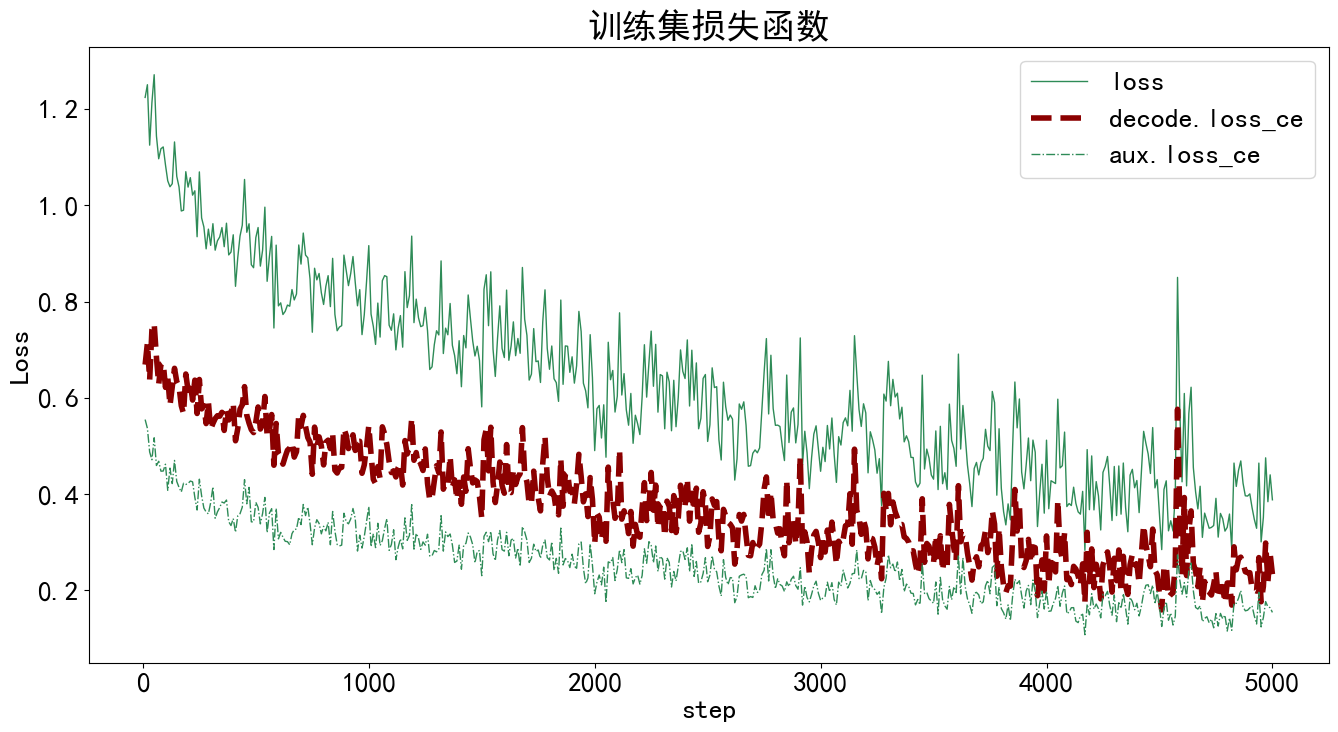

In [15]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Loss', fontsize=20)
plt.title('训练集损失函数', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集损失函数.pdf', dpi=120, bbox_inches='tight')

plt.show()



## 训练集准确率

In [16]:
metrics = ['decode.acc_seg', 'aux.acc_seg']

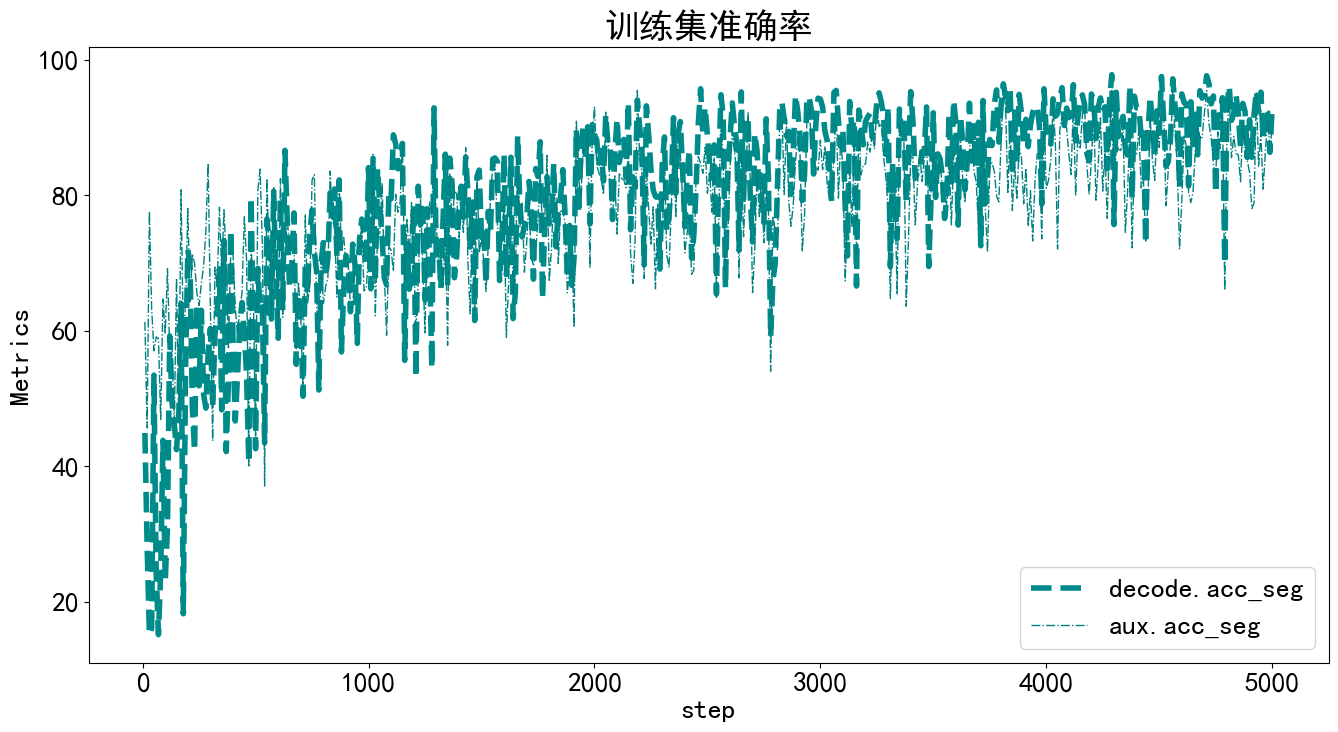

In [17]:
plt.figure(figsize=(16, 8))

x = df_train['step']
for y in metrics:
    try:
        plt.plot(x, df_train[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('训练集准确率', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/训练集准确率.pdf', dpi=120, bbox_inches='tight')

plt.show()

## 测试集评估指标

In [18]:
df_test.columns

Index(['aAcc', 'mIoU', 'mAcc', 'mDice', 'mFscore', 'mPrecision', 'mRecall',
       'data_time', 'time', 'step'],
      dtype='object')

In [19]:
metrics = ['aAcc', 'mIoU', 'mAcc', 'mDice', 'mFscore', 'mPrecision', 'mRecall']

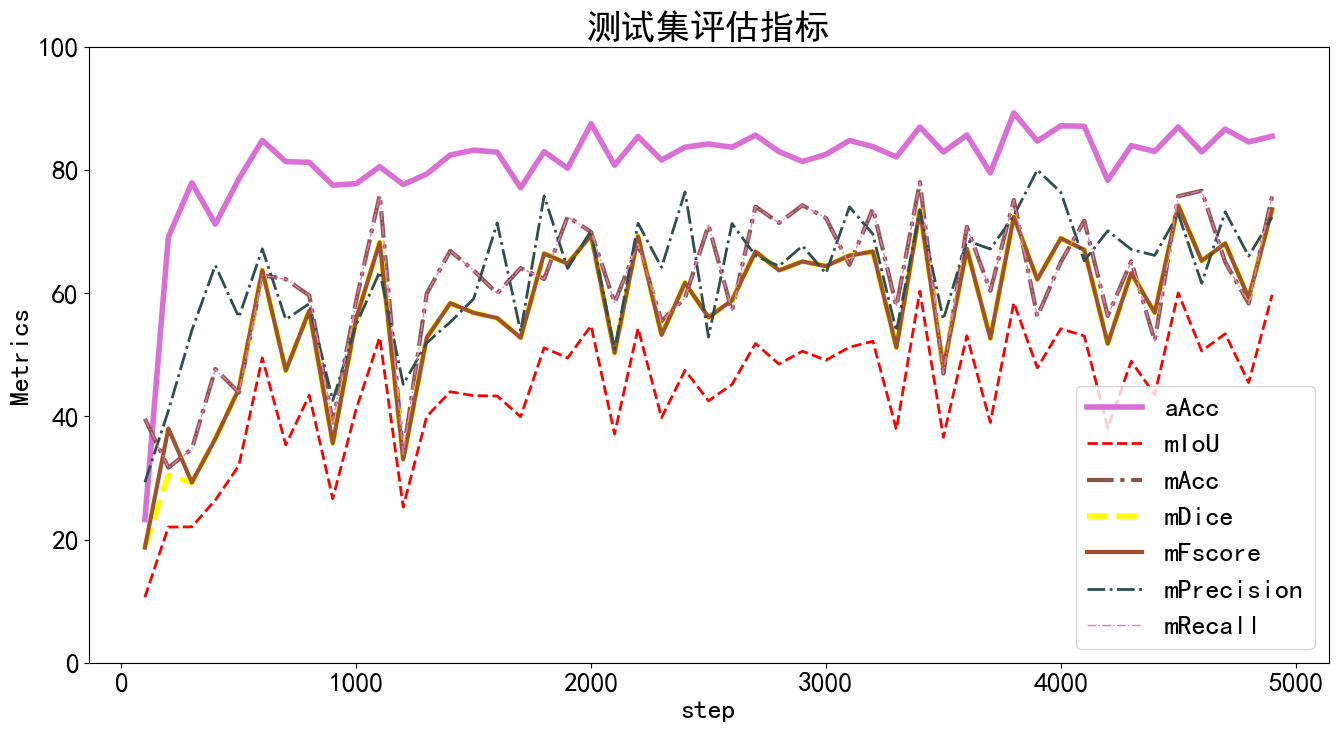

In [20]:
plt.figure(figsize=(16, 8))

x = df_test['step']
for y in metrics:
    try:
        plt.plot(x, df_test[y], label=y, **get_line_arg())
    except:
        pass

plt.tick_params(labelsize=20)
plt.ylim([0, 100])
plt.xlabel('step', fontsize=20)
plt.ylabel('Metrics', fontsize=20)
plt.title('测试集评估指标', fontsize=25)

plt.legend(fontsize=20)

plt.savefig('图表/测试集分类评估指标.pdf', dpi=120, bbox_inches='tight')

plt.show()